<a href="https://colab.research.google.com/github/Davoudasad/ME5920/blob/main/ME592_HW2_Task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 5:** ow-Rank and Sparse Decomposition (Robust PCA Perspective)

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load video
cap = cv2.VideoCapture("football_video.mp4")
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame,(160,90))
    frames.append(frame)

cap.release()
frames = np.array(frames)
T,H,W,C = frames.shape

print(f'Number of frames (T): {T}')
print(f'Frame dimensions: {H} x {W} x {C}')
print(f'Flattened vector length (H*W*C): {H * W * C}')

# Flatten each frame into a row vector and stack into matrix X
X = frames.reshape(T, -1)
print(f'Data matrix X shape: {X.shape}')      # (T, H*W*C)
print(f'Memory usage: {X.nbytes / 1e9:.2f} GB')

# LOW-RANK PCA RECONSTRUCTION
k = 5   # number of PCA components
pca = PCA(n_components=k)
Z = pca.fit_transform(X)
X_lowrank = pca.inverse_transform(Z)

# Sparse component
X_sparse = X - X_lowrank

# reshape back to frames
lowrank_frames = X_lowrank.reshape(T, H, W, C)
sparse_frames = X_sparse.reshape(T, H, W, C)

# Normalize function
def normalize(img):
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    return img

# Sparse magnitude
motion_energy = np.linalg.norm(X_sparse, axis=1)
top_k = 10
top_frames = np.argsort(motion_energy)[-top_k:][::-1]

print("Frames with highest motion:", top_frames)



Number of frames (T): 913
Frame dimensions: 90 x 160 x 3
Flattened vector length (H*W*C): 43200
Data matrix X shape: (913, 43200)
Memory usage: 0.04 GB
Frames with highest motion: [645 646 644 647 643 648 642 641 636 638]


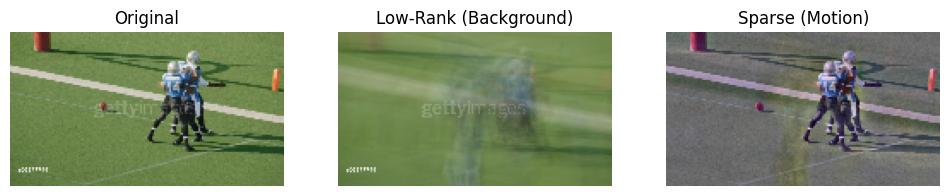

In [13]:
# Low Rank Reconstruction / Sparse component / Normalize sparse maps for display / Show example decomposition
frame_id = T//2
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)

plt.imshow(frames[frame_id].astype(np.uint8))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(lowrank_frames[frame_id].clip(0,255).astype(np.uint8))
plt.title("Low-Rank (Background)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(normalize(sparse_frames[frame_id]))
plt.title("Sparse (Motion)")
plt.axis("off")
plt.show()

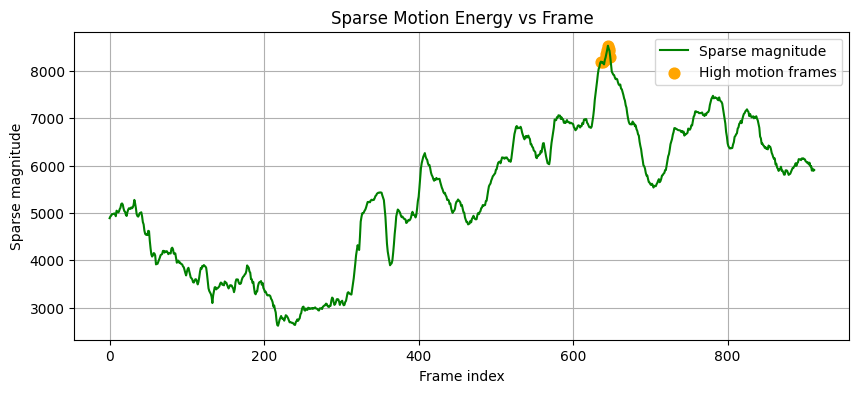

In [14]:
# Sparse magnitude vs frame number for largest sparse magnitude detection
plt.figure(figsize=(10,4))
plt.plot(motion_energy,'g',linewidth=1.5,label='Sparse magnitude')
plt.scatter(top_frames,motion_energy[top_frames],color='orange',s=60,label='High motion frames')
plt.xlabel("Frame index")
plt.ylabel("Sparse magnitude")
plt.title("Sparse Motion Energy vs Frame")
plt.legend()
plt.grid(True)
plt.show()

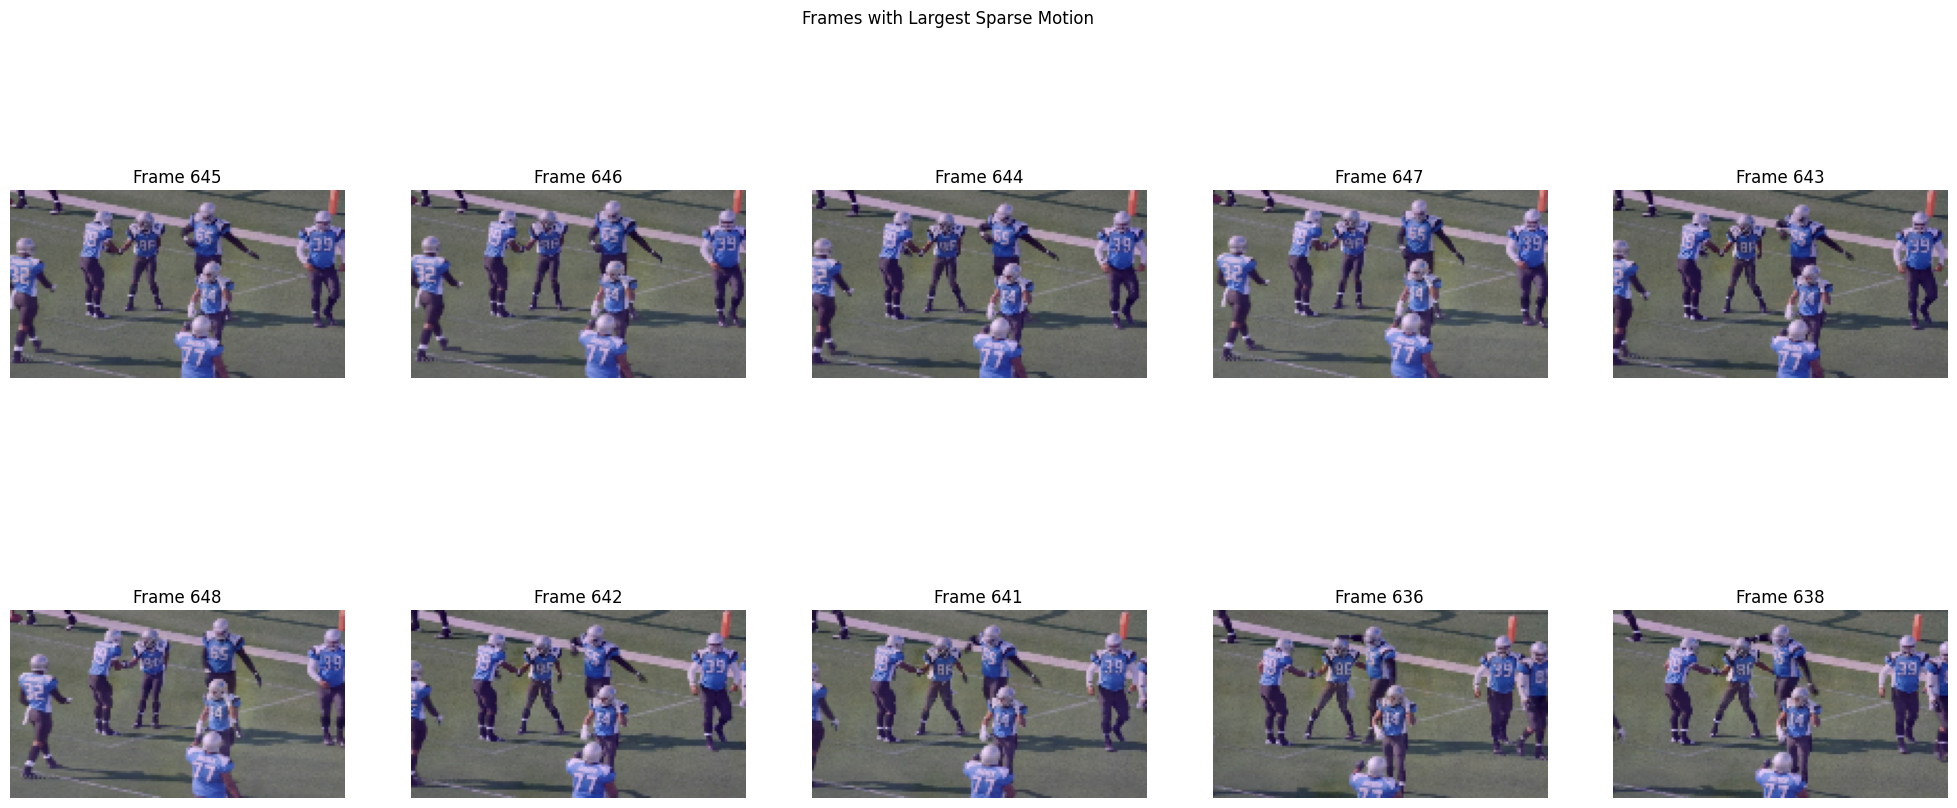

In [15]:
# Plot high motion frames
plt.figure(figsize=(25,10))
for i, idx in enumerate(top_frames):
    plt.subplot(2,5,i+1)
    plt.imshow(normalize(sparse_frames[idx]))
    plt.title(f"Frame {idx}")
    plt.axis("off")
plt.suptitle("Frames with Largest Sparse Motion")
plt.show()

**Whether dynamic objects are effectively isolated in the sparse component, whether subtle motion is captured, and how this decomposi- tion compares with classical PCA-based reconstruction error in isolating meaningful events.**

### The low-rank component captures the static background of the scene, such as the football field and yard lines, while the sparse component highlights dynamic objects like moving players and the ball. As a result, the sparse frames effectively isolate motion by suppressing most of the background. Larger player movements are clearly visible, although very subtle motion may not always be captured strongly because the low-rank model can absorb gradual changes. Compared with classical PCA reconstruction error, the sparse decomposition more directly separates foreground motion from background structure, making meaningful motion events easier to identify.